In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [6]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [7]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [8]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,27646.000000,27646.000000,27646.000000,27646.000000,27646.000000
mean,1.662987,0.099780,0.358476,1.572078,0.006945
std,0.137168,0.498883,0.486354,0.752057,0.999994
min,1.500004,-0.976175,-0.884835,0.400161,-1.000000
25%,1.574556,-0.345046,-0.052246,0.974001,-1.000000
50%,1.628487,0.123664,0.484368,1.452281,1.000000
75%,1.703474,0.547024,0.800381,2.046279,1.000000
max,2.099948,0.998722,0.968485,5.397387,1.000000


In [9]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [10]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,5803.000000,5803.000000,5803.000000,5803.000000,5803.000000
mean,1.878246,0.125321,0.420327,1.615841,0.010512
std,0.137300,0.511916,0.506318,0.828626,1.000031
min,1.730063,-0.973055,-0.884835,0.400161,-1.000000
25%,1.767668,-0.328913,0.017699,0.923894,-1.000000
50%,1.806151,0.166494,0.614319,1.511427,1.000000
75%,2.045427,0.578899,0.866627,2.135456,1.000000
max,2.099948,0.997492,0.968485,5.397387,1.000000


In [11]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [16]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"
# cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/new_FOM/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [17]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [18]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,99332.000000,99332.000000,99332.000000,99332.000000,99332.000000
mean,1.752464,0.093437,0.360303,1.608582,0.001329
std,0.168486,0.505168,0.485837,0.759353,1.000004
min,1.500002,-0.994923,-0.885105,0.400173,-1.000000
25%,1.606766,-0.350701,-0.047446,1.018043,-1.000000
50%,1.714433,0.115519,0.481256,1.484978,1.000000
75%,1.913694,0.544849,0.808340,2.075884,1.000000
max,2.099997,0.998573,0.971912,5.102557,1.000000


In [19]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [20]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,47235.000000,47235.000000,47235.000000,47235.000000,47235.000000
mean,1.908116,0.108460,0.396605,1.598276,-0.005144
std,0.095503,0.501890,0.484721,0.771498,0.999997
min,1.730001,-0.988593,-0.884639,0.400173,-1.000000
25%,1.829376,-0.325186,-0.002896,1.008592,-1.000000
50%,1.926489,0.141195,0.545465,1.476031,-1.000000
75%,1.973163,0.545599,0.842595,2.049730,1.000000
max,2.099997,0.998514,0.969874,5.102557,1.000000


In [21]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [22]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [23]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


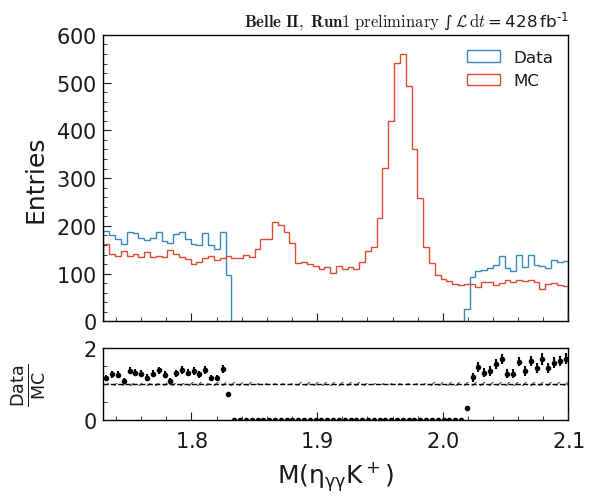

In [24]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")
# ax_main.legend()

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_new_FOM.png", bbox_inches="tight")

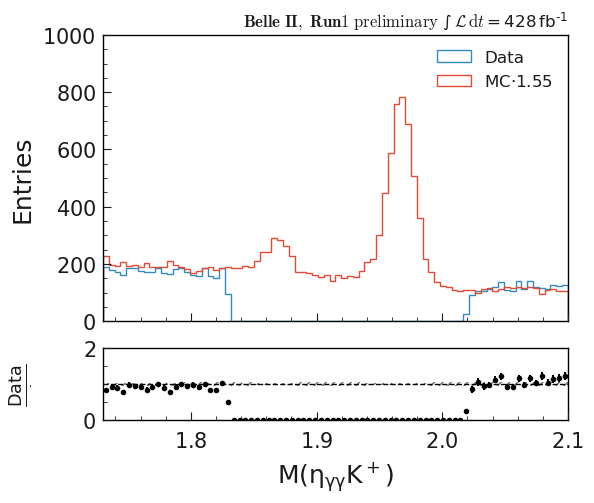

In [26]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*1.40)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label=r"MC$\cdot$1.55",
    comparison="split_ratio",
)

# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")
# ax_main.legend()

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
# fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_new_FOM.png", bbox_inches="tight")